In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import plot_style, norm01; plot_style('notebook');
from utils import generate_stim


### Objective
Figure out what objective makes segmentation optimal.

dict_keys(['stim', 'event_lengths', 'event_boundaries', 'event_feats', 'non_event_feats', 'narrative_template', 'event_relatedness', 'event_templates', 'autoreg_directions'])


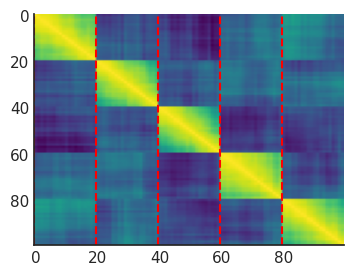

In [2]:
stim_info = generate_stim(stim_dim=50, event_dim=5, n_stims=100, min_events=5, mean_events=5, max_events=5, event_len_var=0, stim_noise=0.05, prop_related_events=0.2, related_event_template_noise=0.05, seed=None)
print(stim_info.keys())
true_stim, true_bounds = stim_info['stim'], stim_info['event_boundaries']

plt.figure(figsize=(4,3))
plt.imshow(np.corrcoef(true_stim.T), aspect='auto', cmap='viridis')
for bound in true_bounds:    plt.axvline(bound-.5, color='red', linestyle='--')
plt.show()

In [3]:
def get_pred_recon_acc(stim_T, bounds, metric='01'):

    event2stims = {i: [] for i in range(len(bounds))}  # dict of len=len(bounds)
    for bound_idx in range(len(bounds)):
        event2stims[bound_idx] = stim_T[:,bounds[bound_idx]:bounds[bound_idx+1]] if bound_idx+1 < len(bounds) else stim_T[:,bounds[bound_idx]:]
    print(f'events (n,t): {[np.shape(val) for key, val in event2stims.items()]}')

    pred_recon_acc = []
    if metric == '01':  print()
    elif metric == '0-1':   print()
    
    return pred_recon_acc

stim_info = generate_stim(stim_dim=50, event_dim=5, n_stims=100, min_events=5, mean_events=5, max_events=5, event_len_var=0, stim_noise=0.05, prop_related_events=0.2, related_event_template_noise=0.05, seed=None)
pred_recon_acc = get_pred_recon_acc(stim_info['stim'], stim_info['event_boundaries'])


events (n,t): [(50, 20), (50, 20), (50, 20), (50, 20), (50, 20)]



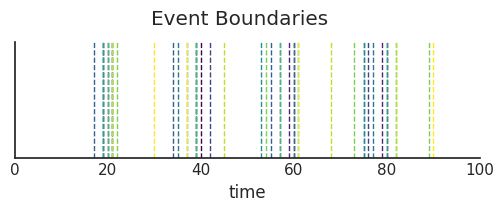

In [4]:
np.random.seed(42)
event_len_vars = np.arange(0, .501, 0.05)
colors = plt.cm.viridis(np.linspace(0, 1, len(event_len_vars)))
pred_recon_accs = []

fig, axs = plt.subplots(figsize=(6, 1.5))
plt.suptitle('Event Boundaries', y=1.1)

for event_len_var in event_len_vars:
    stim_info = generate_stim(stim_dim=50, event_dim=5, n_stims=100, min_events=5, mean_events=5, max_events=5, event_len_var=event_len_var, stim_noise=0.05, prop_related_events=0.2, related_event_template_noise=0.05, seed=None)
    for bound in stim_info['event_boundaries'][1:]:     axs.axvline(bound, color=colors[np.where(event_len_vars == event_len_var)[0][0]], ls='--', lw=1)
    
axs.set(xlim=(0, stim_info['stim'].shape[1]), yticks=[], xlabel='time')
plt.show()
